<a href="https://colab.research.google.com/github/melissa-mariano/fashion-data/blob/main/Green_Is_the_New_Black.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# installation des paquets

In [1]:
!pip install -q Unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 14.1 MB/s eta 0:00:00


In [2]:
!pip install -q pdfplumber requests tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.7/67.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 99.3 MB/s eta 0:00:00


In [3]:
!pip install langdetect -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 46.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [4]:
!pip install -q spacy
!python -m spacy download fr_core_news_sm
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 104.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 78.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [5]:
from unidecode import unidecode
import numpy as np
import pandas as pd
import io, os, time, requests, pdfplumber
from tqdm import tqdm
import re
import spacy
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns


# importation et préparation des données d’entrée

In [6]:
# 1) lecture brute
raw = pd.read_csv("/content/liste-entreprises.csv", encoding="utf-8")

print("Colonnes brutes :", list(raw.columns))

# 2) si tout est venu dans UNE seule colonne, on découpe à la main sur ';'
if raw.shape[1] == 1:
    base = raw.iloc[:, 0].str.split(";", expand=True)
    base.columns = ["Marque", "Pays", "Type", "URL_rapport_RSE"]
else:
    base = raw.copy()

print("Colonnes après split :", list(base.columns))



Colonnes brutes : ['Marque;Pays;Type;URL_rapport_RSE']
Colonnes après split : ['Marque', 'Pays', 'Type', 'URL_rapport_RSE']


In [7]:
base.head()

,Marque,Pays,Type,URL_rapport_RSE
0,LVMH,France,Luxe,doc
1,Kering,France,Luxe,https://www.kering.com/api/download-file/?path...
2,Chanel,France,Luxe,https://www.chanel.com/puls-img/1758110433609-...
3,Hermès,France,Luxe,https://assets-finance.hermes.com/s3fs-public/...
4,Balmain,France,Luxe,https://us.balmain.com/on/demandware.static/-/...


In [8]:
# ---- entrées ----
PATH_CSV = "/content/liste-entreprises.csv"  # contient les colonnes Marque et URL_rapport_RSE
DOC_LVMH = "/content/LVMH_Commited_to_positive_impact-2024.pdf"
DOC_MANGO = "/content/Memoria sostenibilidad 2024_EN.pdf"
DOC_LACOSTE = "/content/2024-LACOSTE-RAPPORT-DENGAGEMENT-DURABLE-ELEGANCE.pdf"

# Nettoyage des espaces et des valeurs manquantes
base["Marque"] = base["Marque"].astype(str).str.strip()
base["URL_rapport_RSE"] = base["URL_rapport_RSE"].astype(str).str.strip()

# Remplacement des liens manquants par les documents locaux
# Si le fichier CSV contient déjà un lien, celui-ci est remplacé par le document local
base.loc[base["Marque"].str.upper().str.contains("LVMH"), "URL_rapport_RSE"] = DOC_LVMH
base.loc[base["Marque"].str.upper().str.contains("MANGO"), "URL_rapport_RSE"] = DOC_MANGO
base.loc[base["Marque"].str.upper().str.contains("LACOSTE"), "URL_rapport_RSE"] = DOC_LACOSTE


# Renommage des colonnes pour obtenir le format final : Marque + Document
base = base.rename(columns={"URL_rapport_RSE": "Document"})[["Marque", "Document"]]

# Création d’un dictionnaire Marque → Document
base_dict = dict(zip(base["Marque"], base["Document"]))

print(f"Nombre total d’entreprises: {len(base)}")
print("Exemples du dictionnaire:", list(base_dict.items())[:5])

Nombre total d’entreprises: 19
Exemples du dictionnaire: [('LVMH', '/content/LVMH_Commited_to_positive_impact-2024.pdf'), ('Kering', 'https://www.kering.com/api/download-file/?path=KERING_RA_24_ALL_FR_PP_96dpi_d1d38ca7d3.pdf'), ('Chanel', 'https://www.chanel.com/puls-img/1758110433609-chanel-sustainability-performance-extract-2024-for-publication.pdf'), ('Hermès', 'https://assets-finance.hermes.com/s3fs-public/node/pdf_file/2025-03/1743155501/250327_hermes_urd2024_fr.pdf?VersionId=sY5wgntTYV3UQRuslye4mLiYlgIXIbj4'), ('Balmain', 'https://us.balmain.com/on/demandware.static/-/Library-Sites-balmain-contentlibrary/default/dwb138ac3a/BALMAIN_DPEF-2023.pdf?srsltid=AfmBOor3xPbk2irCMw6VldH_KTePmhraJ9BSRpiuov7uxXjCvpkQabJ5')]


Outil de recherche d’URL par entreprise

In [9]:
def _norm(s: str) -> str:
    return unidecode(str(s)).strip().lower()

# dictionnaire normalisé → Document (construit à partir de base_dict)
_norm_map = {_norm(n): doc for n, doc in base_dict.items()}

def buscar_documento(nome: str):
    """Tapez 'LVMH' (ou 'lvmh') pour obtenir l’URL/le fichier ; renvoie NaN si introuvable."""
    q = _norm(nome)
    if q in _norm_map:
        return _norm_map[q]
    # recherche secondaire : si aucun résultat exact, on tente une correspondance partielle
    hits = base[base["Marque"].map(_norm).str.contains(q, na=False)]
    return hits["Document"].iloc[0] if not hits.empty else np.nan

# exemplos:
print(buscar_documento("LVMH"))
print(buscar_documento("inditex"))


/content/LVMH_Commited_to_positive_impact-2024.pdf
https://www.inditex.com/itxcomweb/api/media/d6d06b5c-4a2f-431d-915f-ce8ca9e95181/Sustainabilityreport2024.pdf?t=1756810205890




---



Définition de DOCS comme table officielle des données

In [10]:
# définir officiellement
DOCS = base.copy()  # base principale : Marque, Document

# vérifications utiles
print("Linhas totais:", len(DOCS))
print("Sem documento (NaN):", DOCS["Document"].isna().sum())

# doublons
dup_nom = DOCS["Marque"].duplicated(keep=False).sum()
dup_doc = DOCS["Document"].duplicated(keep=False).sum()
print("Nomes duplicados:", dup_nom, "| Documentos duplicados:", dup_doc)

# afficher les cas problématiques (le cas échéant)
if DOCS["Document"].isna().any():
    display(DOCS[DOCS["Document"].isna()].head())

Linhas totais: 19
Sem documento (NaN): 0
Nomes duplicados: 0 | Documentos duplicados: 0


In [11]:
DOCS.head(40)

,Marque,Document
0,LVMH,/content/LVMH_Commited_to_positive_impact-2024...
1,Kering,https://www.kering.com/api/download-file/?path...
2,Chanel,https://www.chanel.com/puls-img/1758110433609-...
3,Hermès,https://assets-finance.hermes.com/s3fs-public/...
4,Balmain,https://us.balmain.com/on/demandware.static/-/...
5,Lacoste,/content/2024-LACOSTE-RAPPORT-DENGAGEMENT-DURA...
6,Etam Groupe,https://etam-groupe.com/wp-content/uploads/202...
7,Galeries Lafayette,https://static1.squarespace.com/static/5c331d9...
8,H&M Group,https://hmgroup.com/wp-content/uploads/2025/03...
9,Inditex,https://www.inditex.com/itxcomweb/api/media/d6...




---



# extraction du texte des rapports

In [12]:
HEADERS = {"User-Agent": "Mozilla/5.0 (Colab-RSE)"}
TIMEOUT = 90

def extrair_texto_de_pdf_obj(fobj) -> str:
    parts = []
    with pdfplumber.open(fobj) as pdf:
        for page in pdf.pages:
            t = page.extract_text() or ""
            parts.append(t)
    return "\n".join(parts)

linhas = []
for _, r in tqdm(DOCS.iterrows(), total=len(DOCS), desc="Extraindo textos"):
    nome   = r["Marque"]
    source = str(r["Document"]).strip()
    status, err, text = "ok", "", ""

    try:
        if source.lower().startswith("http"):
            # téléchargement du PDF en mémoire (sans l’enregistrer sur le disque)
            resp = requests.get(source, headers=HEADERS, timeout=TIMEOUT)
            resp.raise_for_status()
            bio = io.BytesIO(resp.content)
            text = extrair_texto_de_pdf_obj(bio)
        else:
            # fichier local (ex. : LVMH, THALES)
            with open(source, "rb") as f:
                text = extrair_texto_de_pdf_obj(f)
    except Exception as e:
        status, err = "error", str(e)
        text = ""

    linhas.append({
        "Marque": nome,
        "source": source,
        "status": status,
        "word_count": len(text.split()) if text else 0,
        "text": text,
        "error": err
    })

df_textos = pd.DataFrame(linhas)

# corpus unique
corpus = "\n\n".join(df_textos.loc[df_textos["status"]=="ok", "text"].tolist())

print("✅ Extraction terminée.")
print("Lignes:", len(df_textos),
      "| OK:", (df_textos["status"]=="ok").sum(),
      "| Erreurs:", (df_textos["status"]!="ok").sum())
display(df_textos.head(5))


Extraindo textos: 100%|██████████| 19/19 [07:58<00:00, 25.20s/it]


✅ Extraction terminée.
Lignes: 19 | OK: 18 | Erreurs: 1


,Marque,source,status,word_count,text,error
0,LVMH,/content/LVMH_Commited_to_positive_impact-2024...,error,0,,Unexpected EOF
1,Kering,https://www.kering.com/api/download-file/?path...,ok,17872,KERING Rapport d’activité 2024\n\n\n\nMESSAGE ...,
2,Chanel,https://www.chanel.com/puls-img/1758110433609-...,ok,5424,S u s t a i n a b i l i t y\nP e r f o r m a n...,
3,Hermès,https://assets-finance.hermes.com/s3fs-public/...,ok,315437,\nPRÉSENTATION DU GROUPE COMPTES CONSOLIDÉS 36...,
4,Balmain,https://us.balmain.com/on/demandware.static/-/...,ok,10810,balmain\nDeclaration of Extra-Financial Perfor...,


In [13]:
# Filtrer les entreprises avec une erreur
erros = df_textos[df_textos["status"] != "ok"][["Marque", "source", "error"]]

print(f"🚨 Total avec erreur: {len(erros)}")
display(erros)


🚨 Total avec erreur: 1


,Marque,source,error
0,LVMH,/content/LVMH_Commited_to_positive_impact-2024...,Unexpected EOF


In [14]:
df_textos.head()

,Marque,source,status,word_count,text,error
0,LVMH,/content/LVMH_Commited_to_positive_impact-2024...,error,0,,Unexpected EOF
1,Kering,https://www.kering.com/api/download-file/?path...,ok,17872,KERING Rapport d’activité 2024\n\n\n\nMESSAGE ...,
2,Chanel,https://www.chanel.com/puls-img/1758110433609-...,ok,5424,S u s t a i n a b i l i t y\nP e r f o r m a n...,
3,Hermès,https://assets-finance.hermes.com/s3fs-public/...,ok,315437,\nPRÉSENTATION DU GROUPE COMPTES CONSOLIDÉS 36...,
4,Balmain,https://us.balmain.com/on/demandware.static/-/...,ok,10810,balmain\nDeclaration of Extra-Financial Perfor...,


# nettoyage et préparation des données

In [15]:
# vérifier que df_textos existe
assert {"Marque","source","status","text"}.issubset(df_textos.columns), "df_textos est incomplet."

# 1) ne garder que les textes valides (OK)
df_ok = df_textos[df_textos["status"] == "ok"].copy()

# 2) fonction de nettoyage de base
def clean_text(t: str) -> str:
    if not isinstance(t, str):
        return ""
    t = t.replace("\u00ad", "").replace("\ufeff", "")
    t = re.sub(r"-\s*\n\s*", "", t)
    t = re.sub(r"\s*\n\s*", " ", t)
    t = t.lower()
    t = unidecode(t)
    t = re.sub(r"[^a-z0-9\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

# 3) appliquer le nettoyage
df_ok["clean_text"] = df_ok["text"].apply(clean_text)

# 4) vérification
print("Docs OK:", len(df_ok))
print(df_ok[["Marque","word_count"]].head())
print("\nExemplo de clean_text:\n", df_ok.iloc[0]["clean_text"][:500])

# base nettoyée
df_clean = df_ok[["Marque","source","clean_text"]].copy()


Docs OK: 18
    Marque  word_count
1   Kering       17872
2   Chanel        5424
3   Hermès      315437
4  Balmain       10810
5  Lacoste       12960

Exemplo de clean_text:
 kering rapport d activite 2024 message du president 03 2024 a ete une annee de transformation notre histoire est celle d un groupe visionnaire et d adaptation pour kering conscients des defis audacieux et en mouvement depuis notre de notre environnement et des evolutions recentrage sur les activites du luxe en 2013 du secteur du luxe nous avons poursuivi nous avons connu une ascension forte portee avec determination les changements engages par une capacite unique a saisir les opportunites depuis


In [16]:
def detect_lang_safe(text):
    try:
        if isinstance(text, str) and len(text) > 50:
            return detect(text)
        else:
            return "unknown"
    except:
        return "unknown"

df_ok["lang"] = df_ok["text"].apply(detect_lang_safe)

# statistiques de base
print(df_ok["lang"].value_counts())

# afficher un exemple pour chaque langue détectée
for lang in df_ok["lang"].unique():
    exemplo = df_ok[df_ok["lang"] == lang].iloc[0]
    print(f"\n--- {lang.upper()} --- {exemplo['Marque']}")
    print(exemplo["clean_text"][:300])


lang
en         12
fr          5
unknown     1
Name: count, dtype: int64

--- FR --- Kering
kering rapport d activite 2024 message du president 03 2024 a ete une annee de transformation notre histoire est celle d un groupe visionnaire et d adaptation pour kering conscients des defis audacieux et en mouvement depuis notre de notre environnement et des evolutions recentrage sur les activites

--- EN --- Chanel
s u s t a i n a b i l i t y p e r f o r m a n c e e x t r a c t 2 0 2 4 some content extracted from chanel limited annual report for the year ended 31 december 2024 c o n t e n t s 01 sustainability at chanel 2024 highlights 3 02 details on climate related performance 12 03 2024 climate related perf

--- UNKNOWN --- Mango



In [17]:
# modèles légers, uniquement pour la lemmatisation (sans parser/ner)
nlp_fr = spacy.load("fr_core_news_sm", disable=["parser", "ner"])
nlp_en = spacy.load("en_core_web_sm", disable=["parser", "ner"])

# limite de taille par document (en caractères) et découpage si nécessaire
nlp_fr.max_length = 1_000_000
nlp_en.max_length = 1_000_000
CHUNK_SIZE = 100_000  # traitement par morceaux si le texte est trop volumineux

def lemmatize_text_small(text, lang):
    if not isinstance(text, str) or not text.strip():
        return ""
    nlp = nlp_fr if lang.startswith("fr") else nlp_en if lang.startswith("en") else nlp_fr

    lemmas = []
    # découper le texte pour éviter une surcharge mémoire
    for i in range(0, len(text), CHUNK_SIZE):
        chunk = text[i:i+CHUNK_SIZE]
        doc = nlp(chunk)
        lemmas.extend(
            tok.lemma_.lower()
            for tok in doc
            if tok.is_alpha and not tok.is_stop
        )
    return " ".join(lemmas)

lemmas = []
for _, row in tqdm(df_ok.iterrows(), total=len(df_ok), desc="Lemmatisation légère"):
    clean = row["clean_text"]
    lang = row.get("lang", "fr")
    lemmas.append(lemmatize_text_small(clean, lang))

df_ok["lemmas"] = lemmas

# base finale pour l’analyse
df_lem = df_ok[["Marque", "source", "lang", "clean_text", "lemmas"]].copy()

print("✅ Lemmatisation terminée sans dépassement de la mémoire RAM.")
display(df_lem.head())


Lemmatisation légère: 100%|██████████| 18/18 [01:10<00:00,  3.91s/it]


✅ Lemmatisation terminée sans dépassement de la mémoire RAM.


,Marque,source,lang,clean_text,lemmas
1,Kering,https://www.kering.com/api/download-file/?path...,fr,kering rapport d activite 2024 message du pres...,kering rapport d activite message presider ete...
2,Chanel,https://www.chanel.com/puls-img/1758110433609-...,en,s u s t a i n a b i l i t y p e r f o r m a n ...,s u s t n b l t y p e r f o r m n c e e x t r ...
3,Hermès,https://assets-finance.hermes.com/s3fs-public/...,fr,presentation du groupe comptes consolides 369 ...,presentation groupe compte consolide resultat ...
4,Balmain,https://us.balmain.com/on/demandware.static/-/...,en,balmain declaration of extra financial perform...,balmain declaration extra financial performanc...
5,Lacoste,/content/2024-LACOSTE-RAPPORT-DENGAGEMENT-DURA...,fr,vers l elegance durable this label plays fair ...,l elegance durable thi label plays fair rappor...


In [18]:
# vérifier que df_lem existe
assert {"Marque", "lemmas"}.issubset(df_lem.columns)

# --- supprimer les tokens inutiles (d, l, etc.) avant de générer les n-grammes
BAD_TOKENS = {
    "d", "l", "s", "t", "c", "j", "n", "qu",
    "de", "le", "la", "les", "des", "du", "au", "aux",
    "the", "of", "in", "to", "for", "and", "by", "on"
}

def strip_bad_tokens(text):
    if not isinstance(text, str):
        return ""
    toks = text.split()
    keep = [w for w in toks if (len(w) > 1 and w not in BAD_TOKENS)]
    return " ".join(keep)

df_lem["lemmas_ng"] = df_lem["lemmas"].fillna("").apply(strip_bad_tokens)

print("Exemple avant/après:")
print(df_lem.iloc[0]["lemmas"][:200])
print("----")
print(df_lem.iloc[0]["lemmas_ng"][:200])


Exemple avant/après:
kering rapport d activite message presider ete annee transformation histoire d groupe visionnaire d adaptation kering conscient defi audacieux mouvement environnement evolution recentrage activite lux
----
kering rapport activite message presider ete annee transformation histoire groupe visionnaire adaptation kering conscient defi audacieux mouvement environnement evolution recentrage activite luxe sect


In [19]:
THEME_PREFIXES = [
    # --- termos já existentes (mantidos) ---
    "agricultur", "regener",
    "artisan",
    "biodivers",
    "climat",
    "consomm", "respons",
    "eau",
    "econom", "circulair",
    "efficac", "energet",
    "electrif",
    "energi",
    "ethiq",
    "scientifiq",
    "durabl",
    "formation",
    "ia", "respons",
    "inclusion",
    "numeriq", "digit",
    "innov",
    "materi",
    "nutrition",
    "sante",
    "securit",
    "tracabil",
    "transition",
    "decarbon",
    "environn", "environ",


    # Matérias-primas e fibras
    "coton", "cotton",
    "lin", "linen",
    "laine", "wool",
    "cachemir", "cashmere",
    "soie", "silk",
    "cuir", "leather",
    "vegan", "alternativ",
    "polyester", "nylon", "viscose", "tencel", "lyocell",

    # Sustentabilidade têxtil
    "textil", "textile",
    "teinture", "dye", "colorant",
    "chimique", "chemical",
    "microplast",
    "durabilit",
    "biodegrad",
    "ecoconcept", "ecodesign",
    "recycl", "upcycl",

    # Cadeia produtiva & rastreabilidade
    "fournisseur", "supply", "supplychain",
    "atelier", "manufactur", "factory",
    "tailleur",
    "production durable",
    "origine", "traçabil", "traceabil",

    # Moda responsável
    "mode durable",
    "slowfashion",
    "fastfashion",
    "collection durable",
    "ecofashion",
    "responsabilite produit",

    # Condições sociais & trabalho
    "travail", "worker",
    "condition",
    "salaire", "wage",
    "heures", "workinghour",
    "fairtrade", "commerce equitable",
    "droits humains", "right", "human",

    # Impactos ambientais específicos da moda
    "empreinte eau",
    "empreinte carbone",
    "pollut", "dechet textile",
    "surproduction", "overproduct",
    "surconsommation", "overconsum",
]


ACRONYMS = {
    "esg","rse","gri","csrd","sfdr","tcfd","sbti","ghg","co2","rgpd","gdpr","sdg","onu","un","ilo","oecd"
}



# création des n-grammes RSE

In [20]:
def is_rse_token(tok: str) -> bool:
    if tok in ACRONYMS:
        return True
    return any(tok.startswith(p) for p in THEME_PREFIXES)

# =========== FONCTION D’EXTRACTION DES N-GRAMMES À PARTIR DE lemmes_ng ===========
def ngrams_rse(df, ngram_range=(2,2), top_n=30, min_df=2):
    # Point clé : on utilise lemmes_ng, pas lemmes
    texts = df["lemmas_ng"].fillna("").tolist()
    if not texts:
        return pd.DataFrame(columns=["ngram","freq"])

    vec = CountVectorizer(
        ngram_range=ngram_range,
        token_pattern=r"\b\w+\b",
        min_df=min_df
    )
    X = vec.fit_transform(texts)
    terms = vec.get_feature_names_out()
    freqs = X.sum(axis=0).A1

    rows = []
    for term, f in zip(terms, freqs):
        toks = term.split()
        # au moins un token lié à la RSE
        if not any(is_rse_token(t) for t in toks):
            continue
        # ignorer les n-grammes où tous les mots sont identiques (ex : "risque risque")
        if len(set(toks)) == 1:
            continue
        rows.append((term, f))

    out = pd.DataFrame(rows, columns=["ngram","freq"])
    return out.sort_values("freq", ascending=False).head(top_n)

# calcular
top_bi = ngrams_rse(df_lem, ngram_range=(2,2), top_n=30, min_df=2)
top_tri = ngrams_rse(df_lem, ngram_range=(3,3), top_n=30, min_df=2)

print("Bigrammes RSE filtrés:")
display(top_bi)

print("Trigrammes RSE filtrés:")
display(top_tri)

Bigrammes RSE filtrés:


,ngram,freq
2672,supply chain,979
1190,human right,619
2083,raw material,384
1080,ghg emission,327
279,climate change,315
2256,responsabilite social,229
808,environmental impact,182
1310,information environmental,177
834,environmental social,165
521,developpement durable,150


Trigrammes RSE filtrés:


,ngram,freq
379,environmental social governance,121
683,information environmental social,108
1201,social supply chain,83
1166,scope ghg emission,80
1495,worker value chain,71
1422,use circular economy,66
579,human right policy,65
1063,respect human right,56
775,material impact risk,53
1445,value chain worker,48


In [24]:
def ngrams_rse_unigram(df, top_n=50, min_df=2):
    texts = df["lemmas_ng"].fillna("").tolist()
    if not texts:
        return pd.DataFrame(columns=["ngram","freq"])

    vec = CountVectorizer(
        ngram_range=(1,1),
        token_pattern=r"\b\w+\b",
        min_df=min_df
    )
    X = vec.fit_transform(texts)
    terms = vec.get_feature_names_out()
    freqs = X.sum(axis=0).A1

    rows = []
    for term, f in zip(terms, freqs):
        if not is_rse_token(term):
            continue
        if len(term) <= 2:  # ignorer les tokens trop courts
            continue
        rows.append((term, f))

    out = pd.DataFrame(rows, columns=["ngram","freq"])
    return out.sort_values("freq", ascending=False).head(top_n)

top_uni = ngrams_rse_unigram(df_lem, top_n=50, min_df=2)

In [25]:
TOP_N = 10  # nombre de mots par entreprise

def resumo_top_unigrams(df_uni_emp, top_n=TOP_N):
    linhas = []
    for emp, grp in df_uni_emp.groupby("Entreprise"):
        g = grp.sort_values("Frequence", ascending=False).head(top_n)
        termos_formatados = [f"{w} ({int(f)})" for w, f in zip(g["Unigramme"], g["Frequence"])]
        linhas.append({
            "Entreprise": emp,
            "Top_unigrammes_RSE": ", ".join(termos_formatados)
        })
    out = pd.DataFrame(linhas).sort_values("Entreprise")
    return out

# visualisation des résultats

/tmp/ipython-input-3314945614.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-3314945614.py:9: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


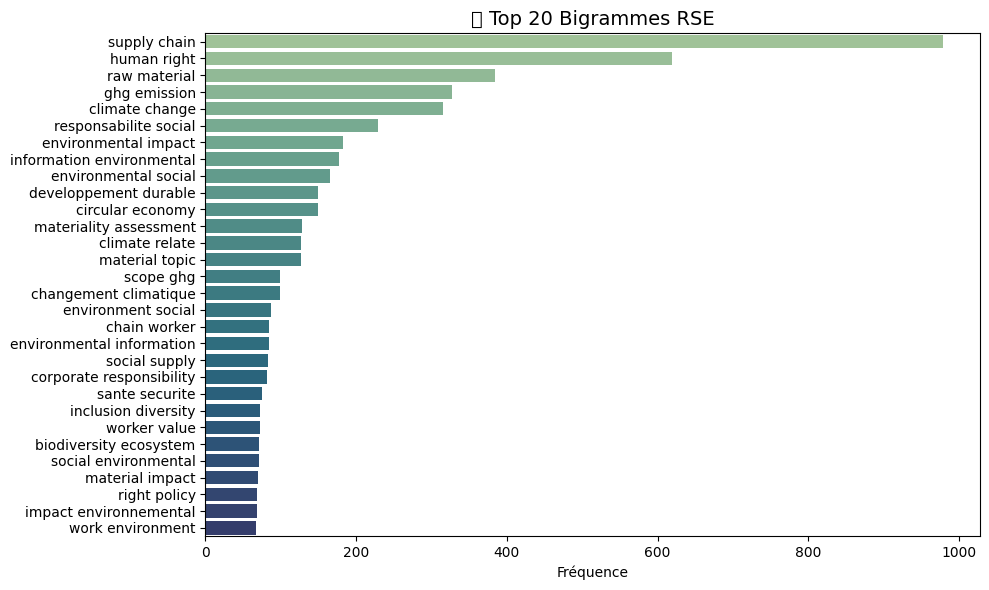

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_bi.sort_values("freq", ascending=False),
    y="ngram", x="freq", palette="crest"
)
plt.title("🟦 Top 20 Bigrammes RSE", fontsize=14)
plt.xlabel("Fréquence")
plt.ylabel("")
plt.tight_layout()
plt.show()


/tmp/ipython-input-433289324.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-433289324.py:9: UserWarning: Glyph 129002 (\N{LARGE PURPLE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129002 (\N{LARGE PURPLE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


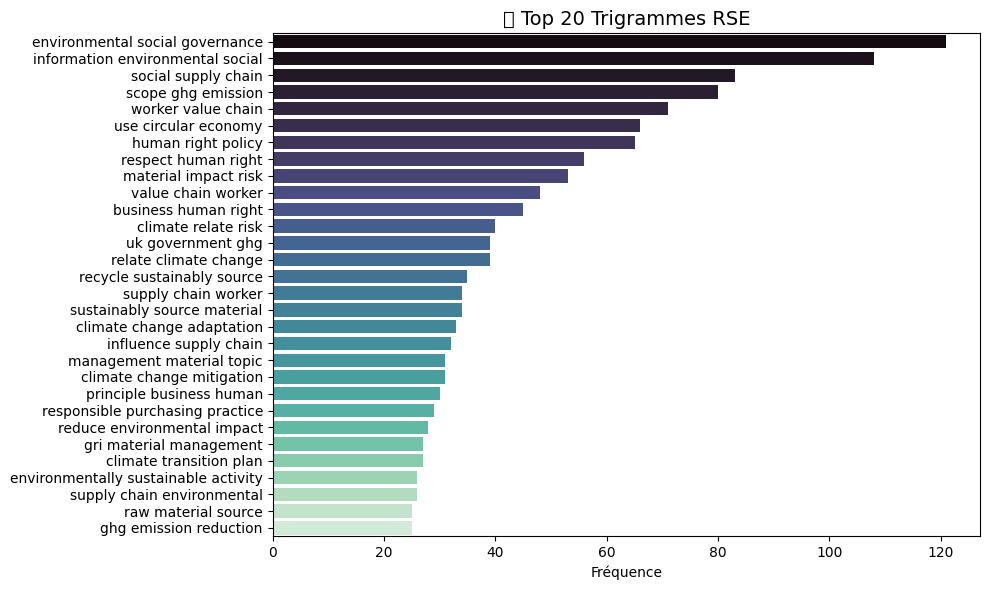

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_tri.sort_values("freq", ascending=False),
    y="ngram", x="freq", palette="mako"
)
plt.title("🟪 Top 20 Trigrammes RSE", fontsize=14)
plt.xlabel("Fréquence")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [28]:
print("Top 50 unigrammes RSE:")
display(top_uni)

Top 50 unigrammes RSE:


,ngram,freq
117,material,1782
179,supply,1143
165,right,1002
76,environmental,956
21,climate,889
92,human,766
202,worker,707
161,responsible,573
80,environnemental,541
88,fournisseur,522


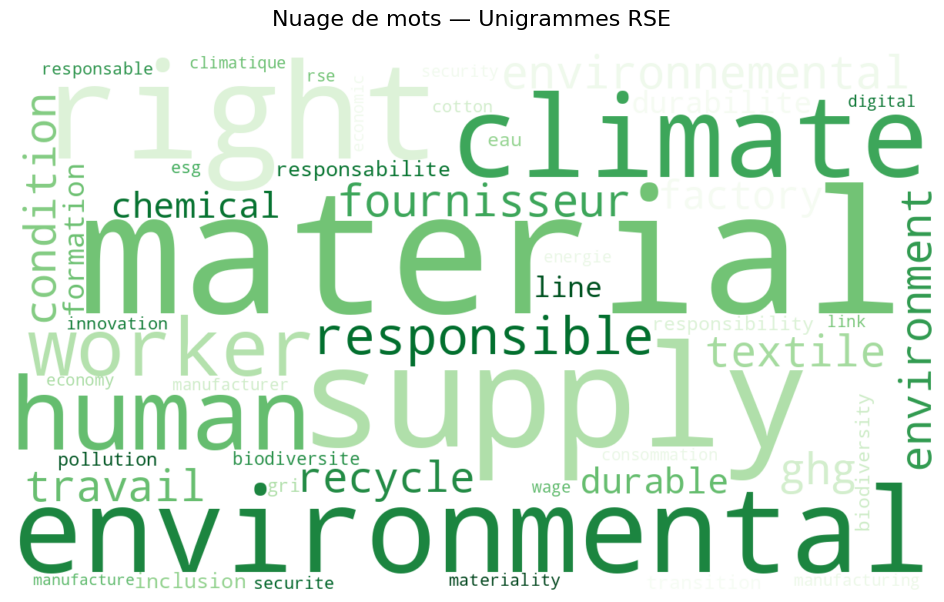

In [29]:
freqs_uni = dict(zip(top_uni["ngram"], top_uni["freq"]))

plt.figure(figsize=(12, 7))
wc_uni = WordCloud(
    width=1200, height=700,
    background_color="white",
    colormap="Greens",
    max_words=100,
    prefer_horizontal=0.9
).generate_from_frequencies(freqs_uni)

plt.imshow(wc_uni, interpolation="bilinear")
plt.axis("off")
plt.title("Nuage de mots — Unigrammes RSE", fontsize=16, pad=20)
plt.show()




---



In [30]:
donnees = df_lem
donnees.columns


Index(['Marque', 'source', 'lang', 'clean_text', 'lemmas', 'lemmas_ng'], dtype='object')

In [31]:
from collections import Counter

def construire_unigrammes_par_entreprise(df_lem):
    lignes = []
    for nom, grp in df_lem.groupby("Marque"):
        # concatène tous les lemmes nettoyés de cette entreprise
        texte = " ".join(grp["lemmas_ng"].dropna().tolist())
        if not texte.strip():
            continue

        tokens = texte.split()
        compteur = Counter()

        for tok in tokens:
            if len(tok) <= 2:
                continue
            if not is_rse_token(tok):
                continue
            compteur[tok] += 1

        for terme, freq in compteur.items():
            lignes.append({
                "Entreprise": nom,
                "Unigramme": terme,
                "Frequence": int(freq)
            })

    return pd.DataFrame(lignes)

df_uni_emp = construire_unigrammes_par_entreprise(df_lem)
display(df_uni_emp.head())
print("Lignes totales df_uni_emp :", len(df_uni_emp))
print("Entreprises couvertes :", df_uni_emp['Entreprise'].nunique())


,Entreprise,Unigramme,Frequence
0,Armani,line,19
1,Armani,materiality,8
2,Armani,regenerative,9
3,Armani,cotton,7
4,Armani,environmental,17


Lignes totales df_uni_emp : 1341
Entreprises couvertes : 17




---



In [32]:
tabela_resumo = resumo_top_unigrams(df_uni_emp, top_n=10)
display(tabela_resumo)

,Entreprise,Top_unigrammes_RSE
0,Armani,"line (19), environmental (17), supply (13), ma..."
1,Balmain,"material (60), responsible (48), environmental..."
2,C&A,"environmental (214), material (207), right (18..."
3,Chanel,"climate (41), ghg (23), supply (16), material ..."
4,Etam Groupe,"fournisseur (68), environnemental (67), respon..."
5,Galeries Lafayette,"travail (61), consommation (42), formation (37..."
6,H&M Group,"material (329), right (237), climate (194), su..."
7,Hermès,"environnemental (389), fournisseur (384), dura..."
8,Inditex,"material (403), climate (309), supply (304), e..."
9,Kering,"durable (38), innovation (29), formation (16),..."


In [33]:
TOP_N = 5  # moins de colonnes pour une meilleure lisibilité

linhas = []
for emp, grp in df_uni_emp.groupby("Entreprise"):
    g = grp.sort_values("Frequence", ascending=False).head(TOP_N)
    row = {"Entreprise": emp}
    for i, (w, f) in enumerate(zip(g["Unigramme"], g["Frequence"]), start=1):
        row[f"term_{i}"] = w
        row[f"freq_{i}"] = int(f)
    linhas.append(row)

tabela_wide = pd.DataFrame(linhas).sort_values("Entreprise")
display(tabela_wide)


,Entreprise,term_1,freq_1,term_2,freq_2,term_3,freq_3,term_4,freq_4,term_5,freq_5
0,Armani,line,19,environmental,17,supply,13,material,13,recycle,9
1,Balmain,material,60,responsible,48,environmental,42,manufacturer,36,condition,19
2,C&A,environmental,214,material,207,right,187,worker,145,human,142
3,Chanel,climate,41,ghg,23,supply,16,material,11,environmental,8
4,Etam Groupe,fournisseur,68,environnemental,67,responsable,43,travail,43,consommation,34
5,Galeries Lafayette,travail,61,consommation,42,formation,37,environnemental,37,responsable,36
6,H&M Group,material,329,right,237,climate,194,supply,156,worker,125
7,Hermès,environnemental,389,fournisseur,384,durabilite,355,travail,344,responsabilite,324
8,Inditex,material,403,climate,309,supply,304,environmental,268,right,255
9,Kering,durable,38,innovation,29,formation,16,eau,12,environnement,10


In [34]:
# --- enregistrer en CSV ---
output_path = "/content/top_unigrammes_RSE_par_entreprise.csv"
tabela_wide.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"✅ Fichier exporté: {output_path}")

Fichier exporté: /content/top_unigrammes_RSE_par_entreprise.csv
